## UCI Distribution Analysis

목적: UCI Online Retail로 SKU 다품종 분포 확인하기 위한 코드

In [11]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [13]:
DATA_DIR = Path("../data/raw")

ITEMS_PATH = DATA_DIR / "olist_order_items_dataset.csv"
ORDERS_PATH = DATA_DIR / "olist_orders_dataset.csv"
PRODUCTS_PATH = DATA_DIR / "olist_products_dataset.csv"
SELLERS_PATH = DATA_DIR / "olist_sellers_dataset.csv"
UCI_PATH = DATA_DIR / "Online Retail.xlsx"

In [14]:
print(UCI_PATH)
print(UCI_PATH.exists())

..\data\raw\Online Retail.xlsx
True


In [16]:
uci = pd.read_excel(UCI_PATH)

# 취소 거래 제거
uci = uci[~uci["InvoiceNo"].astype(str).str.startswith("C")]

# 0 이하 수량 제거
uci = uci[uci["Quantity"] > 0]

# 주문당 distinct SKU 수
sku_per_invoice = (
    uci.groupby("InvoiceNo")["StockCode"]
       .nunique()
)

ratio = (
    sku_per_invoice
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(ratio)

StockCode
1       11.530297
2        4.023543
3        3.333655
4        3.198572
5        3.319182
          ...    
704      0.004824
721      0.004824
731      0.004824
749      0.004824
1110     0.004824
Name: proportion, Length: 366, dtype: float64

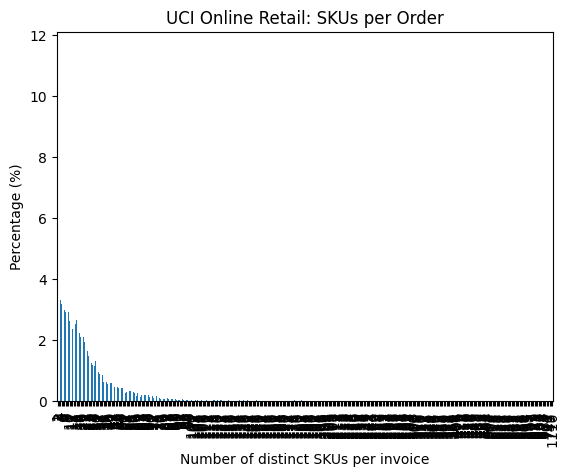

In [17]:
ratio.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order")
plt.show()

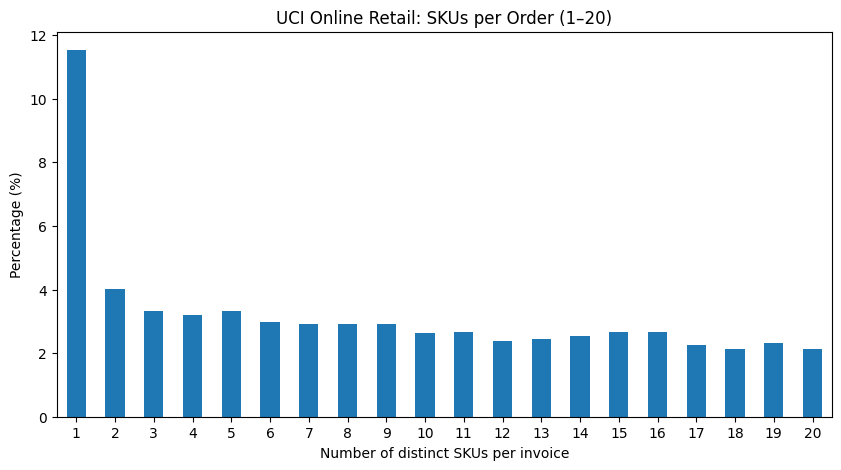

Orders with more than 20 SKUs: 36.06%


In [18]:
# 1~20 SKU 주문만 시각화
ratio_20 = ratio[ratio.index <= 20]

plt.figure(figsize=(10, 5))
ratio_20.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–20)")
plt.xticks(rotation=0)
plt.show()

# 20개 초과 주문 비율
over_20 = ratio[ratio.index > 20].sum()
print(f"Orders with more than 20 SKUs: {over_20:.2f}%")

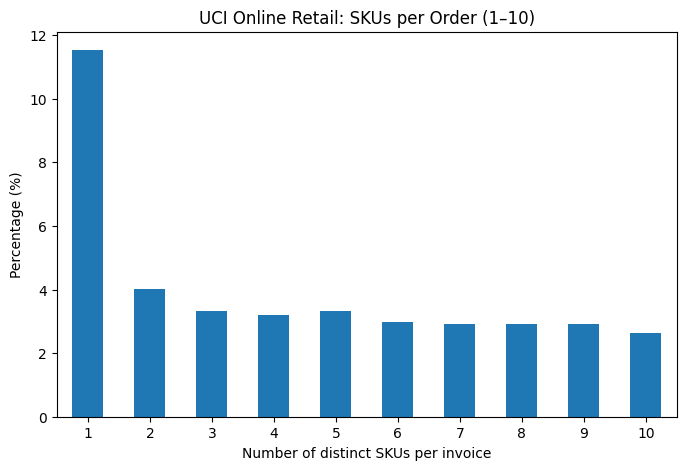

In [19]:
ratio_10 = ratio[ratio.index <= 10]

plt.figure(figsize=(8, 5))
ratio_10.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–10)")
plt.xticks(rotation=0)
plt.show()

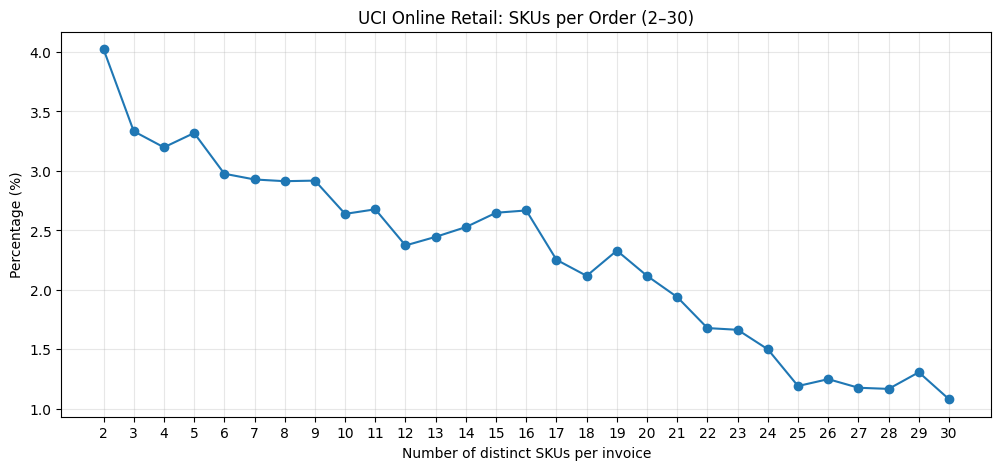

In [20]:
# 1-SKU 제외 + 2~30 SKU만 확대
ratio_zoom = ratio[(ratio.index >= 2) & (ratio.index <= 30)]

plt.figure(figsize=(12, 5))
plt.plot(
    ratio_zoom.index,
    ratio_zoom.values,
    marker="o"
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (2–30)")
plt.xticks(range(2, 31))
plt.grid(alpha=0.3)
plt.show()

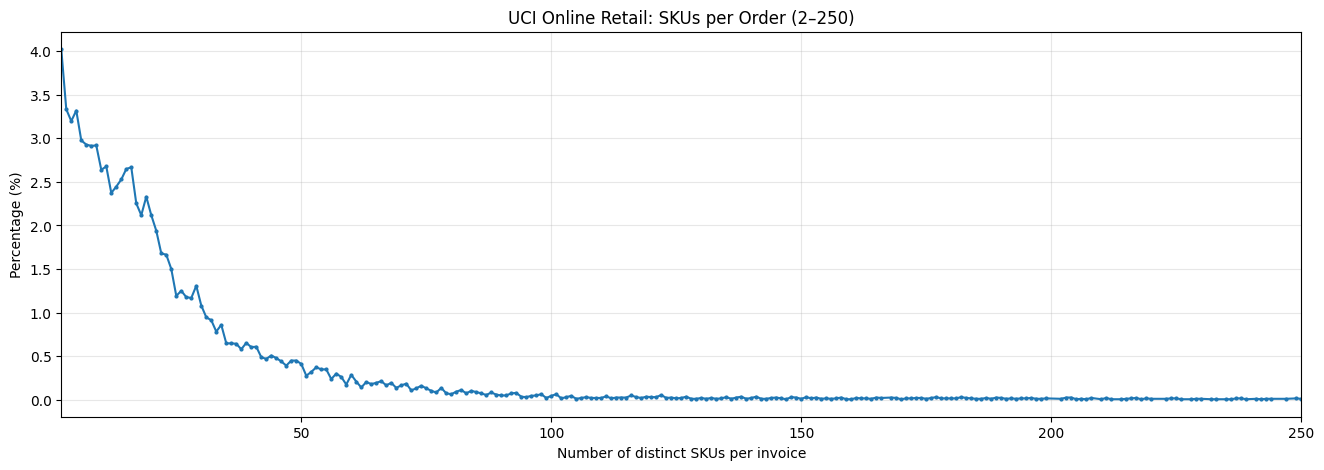

In [21]:
ratio_2_250 = ratio[(ratio.index >= 2) & (ratio.index <= 250)]

plt.figure(figsize=(16, 5))
plt.plot(
    ratio_2_250.index,
    ratio_2_250.values,
    marker="o",
    markersize=2
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (2–250)")
plt.xlim(2, 250)
plt.grid(alpha=0.3)
plt.show()

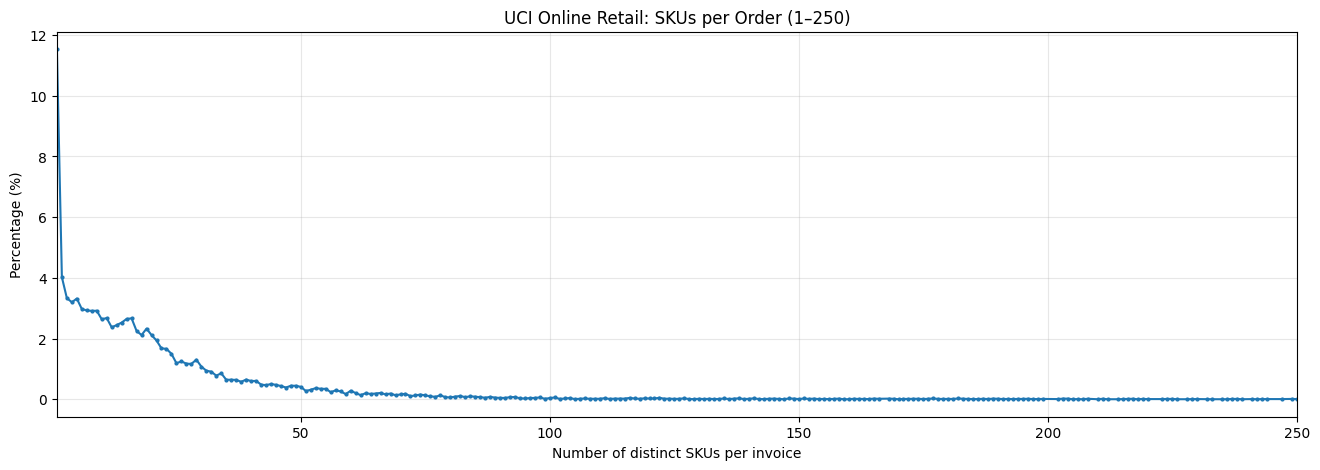

In [22]:
ratio_1_250 = ratio[(ratio.index >= 1) & (ratio.index <= 250)]

plt.figure(figsize=(16, 5))
plt.plot(
    ratio_1_250.index,
    ratio_1_250.values,
    marker="o",
    markersize=2
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–250)")
plt.xlim(1, 250)
plt.grid(alpha=0.3)
plt.show()

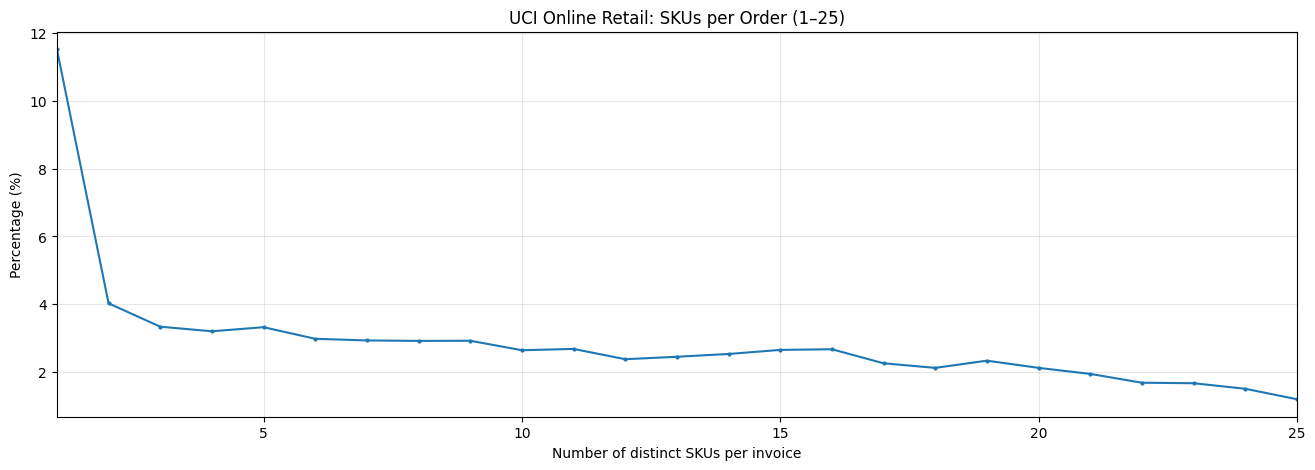

In [26]:
ratio_1_25 = ratio[(ratio.index >= 1) & (ratio.index <= 25)]

plt.figure(figsize=(16, 5))
plt.plot(
    ratio_1_25.index,
    ratio_1_25.values,
    marker="o",
    markersize=2
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–25)")
plt.xlim(1, 25)
plt.grid(alpha=0.3)
plt.show()